### SCRIPT 3: 

Analysis and plots based on the results file with the following format: f0_NX.csv

In [2]:
user = "margherita" #"louise" or "fannie"

In [3]:
## change address and / or user on your computer
if (user == "louise" or user == "fannie"):
    DIR = "/Users/" + user + "/Documents/GitHub/SOA-project-/datasets/"
elif user == "margherita":
    DIR = r"C:/Users/Margherita/Documents/GitHub/SOABB1/Datasets/" # windows address
current_file = "N72_f0_HNR_RMS.csv"

In [4]:
### PARAMETERS OF THE ANALYSIS ###
fts = 12
excl_notvoc = 1 # = 1 to exclude VS and F and W and R and COVOC
if_convert_f0_mel = 1 # if 1: we confert f0 into mels

In [5]:
### IMPORT PACKAGES
import matplotlib.pylab as plt
import numpy as np
import os, glob
import pandas
import seaborn as sns
import re
from scipy import stats
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statannot import add_stat_annotation
import diptest

pandas.options.display.max_columns = 1000
pandas.options.display.max_rows = 2000

# Create repository to save the plots 
output_dir = DIR + "plot_analysis/"
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

condOrder = ["p100","m100", "neutre"]
condColor = ["turquoise", "orchid", "Grey"]

In [6]:
# FUNCTION: COMPUTES COHEN's d - paired
def cohen_d_simple(x,y):
    if type(y) == int:
        d = (np.mean(x) - np.mean(y)) / np.std(x)
    else:
        nx = len(x)
        ny = len(y)
        sd_pooled = np.sqrt(((nx-1)*np.std(x)**2 + (ny-1)*np.std(y)**2) / (nx + ny))
        d = (np.mean(x) - np.mean(y)) / sd_pooled
    return np.round(d,3)

# function to calculate Cohen's d for independent samples
def cohend(d1, d2):
    from numpy import var, mean
    from math import sqrt
    n1, n2 = len(d1), len(d2)
    s1, s2 = var(d1, ddof=1), var(d2, ddof=1)
    s = sqrt(((n1 - 1) * s1 + (n2 - 1) * s2) / (n1 + n2 - 2))
    u1, u2 = mean(d1), mean(d2)
    return (u1 - u2) / s

def significance_bar(ax, x1, x2, y, h, text):
    ax.plot([x1, x1, x2, x2],
            [y, y+h, y+h, y],
            lw=1.5, c='k')

    ax.text((x1+x2)/2, y+h+0.02,
            text,
            ha='center', va='bottom',
            fontsize=12)

## PLOTS AND STATS

In [8]:
### Open file with f0 data
resFile = DIR + current_file
df = pandas.read_csv(resFile, sep=';')

### Add participant details
detailsFile = DIR + "References_audios_bb.xlsx" # to load BB age etc.
details = pandas.read_excel(detailsFile)
details = details[["BB", "age", "sexe", "Mirror_recognition"]]
df = pandas.merge(df, details, on = ["BB"])

df_mum = df.loc[((df["who"] == "M"))] ## KEEPS ONLY the mum
df = df.loc[((df["who"] == "B"))] ## KEEPS ONLY the baby

## recomputes duration to avoid errors
df["duration"] = df["stop_times"] - df["start_times"]
df["BB"] = df["BB"].astype(int) # converts BB number into integer
df_mum["BB"] = df_mum["BB"].astype(int) # converts BB number into integer

df.head()

,index,file,start_times,stop_times,duration,phase,who,voc_type,Reco miroir (0;1;2),BB,delete_group,merge_group,cond,BBvoc_NM,BBvoc_M,othersound_NM,othersound_M,f0m_NM,f0sd_NM,f0pNa_NM,f0c_NM,f0m_M,f0sd_M,f0pNa_M,f0c_M,f0cSD_NM,f0cSD_M,HNR_M,HNR_NM,RMSm_NM,RMSsd_NM,RMSm_M,RMSsd_M,age,sexe,Mirror_recognition
0,0.0,BB1_6M_1403_p100_NM,38.01,38.79,0.78,BL,B,B,NaN,1,NaN,NaN,p100,/BB/BL/BB1_6M_1403_p100_NM_38.01_to_38.79,/BB/BL/BB1_6M_1403_p100_38.01_to_38.79_BL,none,none,583.058213,310.638960,0.146154,523.237621,581.676862,308.015428,0.146154,523.208313,328.124361,328.028831,15.069593,15.139210,399.751780,NaN,390.235571,NaN,6.1,M,NaN
1,1.0,BB1_6M_1403_p100_NM,39.70,40.79,1.09,BL,B,pB,NaN,1,NaN,NaN,p100,/BB/BL/BB1_6M_1403_p100_NM_39.7_to_40.79,/BB/BL/BB1_6M_1403_p100_39.7_to_40.79_BL,/other/BL/BB1_6M_1403_p100_NM_38.79_to_39.7,/other/BL/BB1_6M_1403_p100_38.79_to_39.7_BL,626.534615,152.655562,0.821101,523.237621,628.095641,154.142228,0.821101,523.208313,328.124361,328.028831,5.081931,5.965944,154.964475,NaN,139.821527,NaN,6.1,M,NaN
2,2.0,BB1_6M_1403_p100_NM,43.68,45.95,2.27,BL,B,pB,NaN,1,NaN,NaN,p100,/BB/BL/BB1_6M_1403_p100_NM_43.68_to_45.95,/BB/BL/BB1_6M_1403_p100_43.68_to_45.95_BL,/other/BL/BB1_6M_1403_p100_NM_40.79_to_43.68,/other/BL/BB1_6M_1403_p100_40.79_to_43.68_BL,701.692272,321.441413,0.662555,523.237621,702.346828,322.889523,0.662555,523.208313,328.124361,328.028831,11.191019,11.929249,209.402410,NaN,190.498479,NaN,6.1,M,NaN
3,3.0,BB1_6M_1403_p100_NM,50.00,50.70,0.70,BL,B,S,NaN,1,NaN,NaN,p100,/BB/BL/BB1_6M_1403_p100_NM_50.0_to_50.7,/BB/BL/BB1_6M_1403_p100_50.0_to_50.7_BL,/other/BL/BB1_6M_1403_p100_NM_45.95_to_50.0,/other/BL/BB1_6M_1403_p100_45.95_to_50.0_BL,870.853663,227.406818,0.566524,523.237621,869.763894,226.771471,0.566524,523.208313,328.124361,328.028831,8.744007,9.632715,50.147593,NaN,40.726523,NaN,6.1,M,NaN
4,4.0,BB1_6M_1403_p100_NM,51.84,51.96,0.12,BL,B,V,NaN,1,NaN,NaN,p100,/BB/BL/BB1_6M_1403_p100_NM_51.84_to_51.96,/BB/BL/BB1_6M_1403_p100_51.84_to_51.96_BL,/other/BL/BB1_6M_1403_p100_NM_50.7_to_51.84,/other/BL/BB1_6M_1403_p100_50.7_to_51.84_BL,327.876739,12.713441,0.616667,523.237621,326.294348,11.835344,0.616667,523.208313,328.124361,328.028831,4.971112,6.440182,161.880626,NaN,132.862784,NaN,6.1,M,NaN


In [9]:
## PARTICIPANT DETAILS
nsuj = len(np.unique(df["BB"]))

## any differences in age between groups?
age_m = df.groupby(["cond","BB"])["age"].mean().reset_index()
print("nb BB?", nsuj)
print("nb 6mo?", len(age_m.loc[age_m["age"] >= 5.5]), np.mean(age_m.loc[age_m["age"] >= 5.5, "age"]), np.std(age_m.loc[age_m["age"] >= 5.5, "age"]))
print("nb 3mo?", len(age_m.loc[age_m["age"] < 5.5]), np.mean(age_m.loc[age_m["age"] < 5.5, "age"]), np.std(age_m.loc[age_m["age"] < 5.5, "age"]))

m100_age = age_m.loc[age_m["cond"] == "m100", "age"]
print("m100_age", np.mean(m100_age), np.std(m100_age), len(m100_age))
p100_age = age_m.loc[age_m["cond"] == "p100", "age"]
print("p100_age", np.mean(p100_age), np.std(p100_age), len(p100_age))
neutre_age = age_m.loc[age_m["cond"] == "neutre", "age"]
print("neutre", np.mean(neutre_age), np.std(neutre_age), len(neutre_age))
print(stats.ttest_ind(m100_age, p100_age)) # , nan_policy="omit"

nb BB? 72
nb 6mo? 36 6.269444444453703 0.24157086222830432
nb 3mo? 36 3.7787037037129627 0.20520281712746383
m100_age 5.0680000000000005 1.2768182677612696 25
p100_age 4.995652173927536 1.2667926843274113 23
neutre 5.005555555569445 1.2507281829733414 24
TtestResult(statistic=0.19270887321834054, pvalue=0.8480352772504051, df=46.0)


In [10]:
# Age all data mean and std:
print("age all", np.mean(age_m["age"]), np.std(age_m["age"]))

age all 5.024074074083334 1.2653772948072919


In [11]:
## Retrive vocalisation type:
df["Type_protophone"] = df["voc_type"].astype(str)
df["Type_voc"] = "Reflexive sound"
df.loc[np.isin(df["Type_protophone"], ['B', 'Gr', 'S', 'V', 'pB']), "Type_voc"] = "Protophone"
df["is_babbling"] = 0
df.loc[np.isin(df["Type_protophone"], ['B']), "is_babbling"] = 1
df["is_margbabbling"] = 0
df.loc[np.isin(df["Type_protophone"], ['B', 'V', 'pB']), "is_margbabbling"] = 1

# list sub
sujlist = np.unique(df["BB"])
print(sujlist, len(sujlist))

[  1  12  15  18  21  23  24  27  31  36  38  45  47  52  56  58  61  66
  68  69  70  71  72  74  77  78  81  88  90  91  92  94  96  99 100 101
 103 104 109 110 111 112 114 115 116 117 118 119 120 121 122 123 125 127
 129 130 131 133 134 141 142 143 144 148 149 150 155 156 159 160 161 163] 72


In [12]:
#### PREPROCESSING

## TO EXCLUDE Vegetative sounds & fussing sounds & whispers & covocalisations & raspberries
if excl_notvoc: # 'W', "CoV", "VS","F","Cr"
    df = df.loc[df["Type_protophone"] != "W"]
    df = df.loc[df["Type_protophone"] != "CoV"]
    df = df.loc[df["Type_protophone"] != "VS"]
    df = df.loc[df["Type_protophone"] != "F"]
    df = df.loc[df["Type_protophone"] != "Cr"]
#    df = df.loc[df["Type_protophone"] != "L"]

### COUNTS VOCALIZATIONS /BB /phase
for s in np.unique(df["BB"]):
    for p in ['BL', 'EXP']:
        cur = df.loc[((df["BB"] == s) & (df["phase"] == p))].sort_values("start_times")
        cur["voc_nb"] = np.arange(len(cur))+1
        df.loc[((df["BB"] == s) & (df["phase"] == p)), "voc_nb"] = np.array(cur["voc_nb"])
        
    ## OVERALL (not per phase)
    cur = df.loc[((df["BB"] == s))].sort_values("start_times")
    cur["voc_nb_all"] = np.arange(len(cur))+1
    df.loc[((df["BB"] == s)), "voc_nb_all"] = np.array(cur["voc_nb_all"])

## COUNTS NB OF VOCS    
count_vocs = df.groupby(["BB",'age'])["voc_nb_all"].max().reset_index(name="total_nb_voc")
df = pandas.merge(df, count_vocs, on = ["BB", "age"])

sujlist = np.unique(df["BB"])
print(sujlist, len(sujlist))

## COMPUTES THE %protophones per infant
count_protophones = df.groupby(["Type_voc", "BB"])["age"].count().reset_index(name="nb_protophones").sort_values("BB")
count_protophones = count_protophones.loc[count_protophones["Type_voc"] == "Protophone"]
df = pandas.merge(df, count_protophones[["nb_protophones", "BB"]], on = "BB")

## RENAME A FEW COLUMNS SO WE UNDERSTAND WHAT THEY ARE A BIT MORE EASILY ;)
df["age_c"] = 6
df.loc[df["age"] < 5, "age_c"] = 4

[  1  12  15  18  21  23  24  27  31  36  38  45  47  52  56  58  61  66
  68  69  70  71  72  74  77  78  81  88  90  91  92  94  96  99 100 101
 103 104 109 110 111 112 114 115 116 117 118 119 120 121 122 123 125 127
 129 130 131 133 134 141 142 143 144 148 149 150 155 156 159 160 161 163] 72


In [13]:
### Permute condition (CONTROL ANALYSIS)

# Get unique pairs of bb-cond
participants = df[['file', 'cond']].drop_duplicates()
conditions = ['m100', 'p100']

#PERMUTE:
np.random.seed(1)  # for reproducibility
participants['perm_cond'] = np.random.choice(conditions, size=len(participants))

# drop the 'cond'
participants = participants[['file', 'perm_cond']]

# merge with df
df = df.merge(participants, on='file', how='left')

In [14]:
### CONVERTS F0 TO MELs (recommended) or CENT
# FROM Praat (Boersma & Weenink 2019) uses the formula: mel = 550 * ln(1+f/550)
if if_convert_f0_mel: #RECOMMENDED
    for u in ["f0m_NM", "f0m_M"]:
        df[u] = 550 * np.log(1+df[u]/550)
        df_mum[u] = 550 * np.log(1+df_mum[u]/550)
    difference_legend = "output - input (mel)"
df["M_minus_NM"] = df["f0m_M"] - df["f0m_NM"] # 4 BB
df_mum["M_minus_NM"] = df_mum["f0m_M"] - df_mum["f0m_NM"] # F M

In [15]:
### CREATES SEPARATE DF FOR EXP AND BASELINE phases
baseline = df.loc[df["phase"] == "BL"]  # select only the baseline

### COMPUTES MEAN F0 FOR EACH phase & EACH BB for NM and M files for infant voc
baseline_m = baseline.groupby(["BB", "cond", "perm_cond"])[["f0m_NM", "f0m_M","HNR_NM", "HNR_M","RMSm_NM", "RMSm_M"]].mean().reset_index()
baseline_m = baseline_m.rename(columns={"f0m_NM": "baseline_mean_f0_NM", "f0m_M": "baseline_mean_f0_M",
                                       "HNR_NM": "baseline_mean_HNR_NM", "HNR_M": "baseline_mean_HNR_M",
                                       "RMSm_NM": "baseline_mean_RMSm_NM", "RMSm_M": "baseline_mean_RMSm_M"})
df = pandas.merge(df, baseline_m, on = ["BB", "cond", "perm_cond"])

### COMPUTES STD F0 FOR EACH phase & EACH BB for NM and M files for infant voc
baseline_sd = baseline.groupby(["BB", "cond", "perm_cond"])[["f0m_NM", "f0m_M","HNR_NM", "HNR_M","RMSm_NM", "RMSm_M"]].std().reset_index()
baseline_sd = baseline_sd.rename(columns={"f0m_NM": "baseline_std_f0_NM", "f0m_M": "baseline_std_f0_M",
                                       "HNR_NM": "baseline_std_HNR_NM", "HNR_M": "baseline_std_HNR_M",
                                       "RMSm_NM": "baseline_std_RMSm_NM", "RMSm_M": "baseline_std_RMSm_M"})
df = pandas.merge(df, baseline_sd, on = ["BB", "cond", "perm_cond"])
    
## COMPUTES Z-SCORE / BASELINE for each vocalisation in the NM files for BB vocs
## zf0 = (f0 - f0_meanB_baseline) / f0_sdB_baseline 
df["zf0_Original"] = (df["f0m_NM"] - df["baseline_mean_f0_NM"]) / df["baseline_std_f0_NM"]
df["zf0_Original_inv"] = df["zf0_Original"]
df.loc[df["cond"] == "p100", "zf0_Original_inv"] = -df.loc[df["cond"] == "p100", "zf0_Original_inv"]
df.loc[df["cond"] == "neutre", "zf0_Original_inv"] = np.nan
df["zf0_Original_abs"] = abs(df["zf0_Original"]) # magnitude of the change between EXP and BASELINE
df["difference_inv"] = df["M_minus_NM"] # magnitude of the change between EXP and BASELINE
df.loc[df["cond"] == "p100", "difference_inv"] = -df.loc[df["cond"] == "p100", "difference_inv"]
df.loc[df["cond"] == "neutre", "difference_inv"] = np.nan

## COMPUTES Z-SCORE / BASELINE for HNR & RMS
df["zHNR_Original"] = (df["HNR_NM"] - df["baseline_mean_HNR_NM"]) / df["baseline_std_HNR_NM"]
df["zRMS_Original"] = (df["RMSm_NM"] - df["baseline_mean_RMSm_NM"]) / df["baseline_std_RMSm_NM"]

## computes z_score for concatenated data - f0cSD_M & f0c_NM
dfc = df.groupby(["BB", "cond", "perm_cond", "phase","age","age_c"])[["f0c_NM", "f0c_M", "f0cSD_NM", "f0cSD_M"]].mean().reset_index()
dfc["M_minus_NM"] = dfc["f0c_M"] - dfc["f0c_NM"]
dfc_baseline = dfc.loc[dfc["phase"] == "BL"].reset_index()  # select baseline only
dfc_exp = dfc.loc[dfc["phase"] == "EXP"].reset_index()  # select exp phase only
dfc_exp["zf0c_Original"] = (dfc_exp["f0c_NM"] - dfc_baseline["f0c_NM"]) / dfc_baseline["f0cSD_NM"]
dfc_exp["zf0c_Original_inv"] = dfc_exp["zf0c_Original"]
dfc_exp.loc[dfc_exp["cond"] == "p100", "zf0c_Original_inv"] = -dfc_exp.loc[dfc_exp["cond"] == "p100", "zf0c_Original_inv"]
dfc_exp.loc[dfc_exp["cond"] == "neutre", "zf0c_Original_inv"] = np.nan

## SEPARATES PHASES
exp = df.loc[df["phase"] == "EXP"]  # select exp phase only
count_vocs_exp = exp.groupby(["BB",'age'])["voc_nb"].max().reset_index(name="exp_nb_voc")
exp = pandas.merge(exp, count_vocs_exp, on = ["BB", "age"])

bl = df.loc[df["phase"] == "BL"]  # select bl phase only
count_vocs_bl = bl.groupby(["BB",'age'])["voc_nb"].max().reset_index(name="bl_nb_voc")
exp = pandas.merge(exp, count_vocs_bl, on = ["BB", "age"])

df.head(10)

,index,file,start_times,stop_times,duration,phase,who,voc_type,Reco miroir (0;1;2),BB,delete_group,merge_group,cond,BBvoc_NM,BBvoc_M,othersound_NM,othersound_M,f0m_NM,f0sd_NM,f0pNa_NM,f0c_NM,f0m_M,f0sd_M,f0pNa_M,f0c_M,f0cSD_NM,f0cSD_M,HNR_M,HNR_NM,RMSm_NM,RMSsd_NM,RMSm_M,RMSsd_M,age,sexe,Mirror_recognition,Type_protophone,Type_voc,is_babbling,is_margbabbling,voc_nb,voc_nb_all,total_nb_voc,nb_protophones,age_c,perm_cond,M_minus_NM,baseline_mean_f0_NM,baseline_mean_f0_M,baseline_mean_HNR_NM,baseline_mean_HNR_M,baseline_mean_RMSm_NM,baseline_mean_RMSm_M,baseline_std_f0_NM,baseline_std_f0_M,baseline_std_HNR_NM,baseline_std_HNR_M,baseline_std_RMSm_NM,baseline_std_RMSm_M,zf0_Original,zf0_Original_inv,zf0_Original_abs,difference_inv,zHNR_Original,zRMS_Original
0,0.0,BB1_6M_1403_p100_NM,38.01,38.79,0.78,BL,B,B,NaN,1,NaN,NaN,p100,/BB/BL/BB1_6M_1403_p100_NM_38.01_to_38.79,/BB/BL/BB1_6M_1403_p100_38.01_to_38.79_BL,none,none,397.516549,310.638960,0.146154,523.237621,396.845615,308.015428,0.146154,523.208313,328.124361,328.028831,15.069593,15.139210,399.751780,NaN,390.235571,NaN,6.1,M,NaN,B,Protophone,1,1,1.0,1.0,29.0,29,6,p100,-0.670934,403.748376,404.39553,10.638562,10.34564,218.951191,191.515574,115.871357,117.555896,4.729223,4.899935,141.164031,116.551884,-0.053782,0.053782,0.053782,0.670934,0.951668,1.280784
1,1.0,BB1_6M_1403_p100_NM,39.70,40.79,1.09,BL,B,pB,NaN,1,NaN,NaN,p100,/BB/BL/BB1_6M_1403_p100_NM_39.7_to_40.79,/BB/BL/BB1_6M_1403_p100_39.7_to_40.79_BL,/other/BL/BB1_6M_1403_p100_NM_38.79_to_39.7,/other/BL/BB1_6M_1403_p100_38.79_to_39.7_BL,418.225694,152.655562,0.821101,523.237621,418.954950,154.142228,0.821101,523.208313,328.124361,328.028831,5.081931,5.965944,154.964475,NaN,139.821527,NaN,6.1,M,NaN,pB,Protophone,0,1,2.0,2.0,29.0,29,6,p100,0.729256,403.748376,404.39553,10.638562,10.34564,218.951191,191.515574,115.871357,117.555896,4.729223,4.899935,141.164031,116.551884,0.124943,-0.124943,0.124943,-0.729256,-0.988031,-0.453279
2,2.0,BB1_6M_1403_p100_NM,43.68,45.95,2.27,BL,B,pB,NaN,1,NaN,NaN,p100,/BB/BL/BB1_6M_1403_p100_NM_43.68_to_45.95,/BB/BL/BB1_6M_1403_p100_43.68_to_45.95_BL,/other/BL/BB1_6M_1403_p100_NM_40.79_to_43.68,/other/BL/BB1_6M_1403_p100_40.79_to_43.68_BL,452.283400,321.441413,0.662555,523.237621,452.570940,322.889523,0.662555,523.208313,328.124361,328.028831,11.191019,11.929249,209.402410,NaN,190.498479,NaN,6.1,M,NaN,pB,Protophone,0,1,3.0,3.0,29.0,29,6,p100,0.287540,403.748376,404.39553,10.638562,10.34564,218.951191,191.515574,115.871357,117.555896,4.729223,4.899935,141.164031,116.551884,0.418870,-0.418870,0.418870,-0.287540,0.272917,-0.067643
3,3.0,BB1_6M_1403_p100_NM,50.00,50.70,0.70,BL,B,S,NaN,1,NaN,NaN,p100,/BB/BL/BB1_6M_1403_p100_NM_50.0_to_50.7,/BB/BL/BB1_6M_1403_p100_50.0_to_50.7_BL,/other/BL/BB1_6M_1403_p100_NM_45.95_to_50.0,/other/BL/BB1_6M_1403_p100_45.95_to_50.0_BL,522.002175,227.406818,0.566524,523.237621,521.580173,226.771471,0.566524,523.208313,328.124361,328.028831,8.744007,9.632715,50.147593,NaN,40.726523,NaN,6.1,M,NaN,S,Protophone,0,0,4.0,4.0,29.0,29,6,p100,-0.422002,403.748376,404.39553,10.638562,10.34564,218.951191,191.515574,115.871357,117.555896,4.729223,4.899935,141.164031,116.551884,1.020561,-1.020561,1.020561,0.422002,-0.212688,-1.195798
4,4.0,BB1_6M_1403_p100_NM,51.84,51.96,0.12,BL,B,V,NaN,1,NaN,NaN,p100,/BB/BL/BB1_6M_1403_p100_NM_51.84_to_51.96,/BB/BL/BB1_6M_1403_p100_51.84_to_51.96_BL,/other/BL/BB1_6M_1403_p100_NM_50.7_to_51.84,/other/BL/BB1_6M_1403_p100_50.7_to_51.84_BL,257.173355,12.713441,0.616667,523.237621,256.181073,11.835344,0.616667,523.208313,328.124361,328.028831,4.971112,6.440182,161.880626,NaN,132.862784,NaN,6.1,M,NaN,V,Protophone,0,1,5.0,5.0,29.0,29,6,p100,-0.992281,403.748376,404.39553,10.638562,10.34564,218.951191,191.515574,115.871357,117.555896,4.729223,4.899935,141.164031,116.551884,-1.264981,1.264981,1.264981,0.992281,-0.887753,-0.404285
5,5.0,BB1_6M_1403_p100_NM,53.56,54.90,1.34,BL,B,Gr,NaN,1,NaN,NaN,p100,/BB/BL/BB1_6M_1403_p100_NM_53.56_to_54.9,/BB/BL/BB1_6M_1403_p100_53

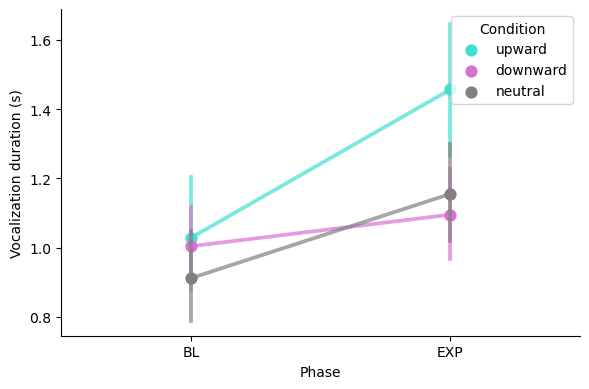

In [16]:
# voc duration check
plt.figure(figsize=(6,4))

sns.pointplot(
    data=df,
    x="phase",
    y="duration",
    hue="cond",
    palette=condColor,
    errorbar=("ci", 95)
)

for line in plt.gca().lines:
    line.set_alpha(0.7)

sns.despine()

plt.xlabel("Phase")
plt.ylabel("Vocalization duration (s)")

handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(
    handles,
    ["upward", "downward", "neutral"],
    frameon=True,
    loc="best",
    fontsize=10,
    title="Condition"
)

# save figure
filename = f"FIGURE_S8_vocdur.png"
filepath = os.path.join(output_dir, filename)
plt.tight_layout(pad=0.3)
plt.savefig(filepath, dpi=300, bbox_inches="tight")

filename_pdf = f"FIGURE_S8_vocdur.pdf"
filepath_pdf = os.path.join(output_dir, filename_pdf)
plt.tight_layout()
plt.savefig(filepath_pdf)

In [17]:
### SAME FOR THE MUM
baseline_mum = df_mum.loc[df_mum["phase"] == "BL"]  # select only baseline_mum

### COMPUTES MEAN F0 FOR EACH phase & EACH BB for NM and M files for infant voc
baseline_mum_m = baseline_mum.groupby(["BB", "cond"])[["f0m_NM", "f0m_M","HNR_NM", "HNR_M","RMSm_NM", "RMSm_M"]].mean().reset_index()
baseline_mum_m = baseline_mum_m.rename(columns={"f0m_NM": "baseline_mum_mean_f0_NM", "f0m_M": "baseline_mum_mean_f0_M",
                                       "HNR_NM": "baseline_mum_mean_HNR_NM", "HNR_M": "baseline_mum_mean_HNR_M",
                                       "RMSm_NM": "baseline_mum_mean_RMSm_NM", "RMSm_M": "baseline_mum_mean_RMSm_M"})
df_mum = pandas.merge(df_mum, baseline_mum_m, on = ["BB", "cond"])

### COMPUTES STD F0 FOR EACH phase & EACH BB for NM and M files for infant voc
baseline_mum_sd = baseline_mum.groupby(["BB", "cond"])[["f0m_NM", "f0m_M","HNR_NM", "HNR_M","RMSm_NM", "RMSm_M"]].std().reset_index()
baseline_mum_sd = baseline_mum_sd.rename(columns={"f0m_NM": "baseline_mum_std_f0_NM", "f0m_M": "baseline_mum_std_f0_M",
                                       "HNR_NM": "baseline_mum_std_HNR_NM", "HNR_M": "baseline_mum_std_HNR_M",
                                       "RMSm_NM": "baseline_mum_std_RMSm_NM", "RMSm_M": "baseline_mum_std_RMSm_M"})
df_mum = pandas.merge(df_mum, baseline_mum_sd, on = ["BB", "cond"])
    
## COMPUTES Z-SCORE / baseline_mum for each vocalisation in the NM files for BB vocs
## zf0 = (f0 - f0_meanB_baseline_mum) / f0_sdB_baseline_mum
df_mum["zf0_Original"] = (df_mum["f0m_NM"] - df_mum["baseline_mum_mean_f0_NM"]) / df_mum["baseline_mum_std_f0_NM"]
df_mum["zf0_Original_inv"] = df_mum["zf0_Original"]
df_mum.loc[df_mum["cond"] == "p100", "zf0_Original_inv"] = -df_mum.loc[df_mum["cond"] == "p100", "zf0_Original_inv"]
df_mum.loc[df_mum["cond"] == "neutre", "zf0_Original_inv"] = np.nan

## computes z_score for concatenated data - f0cSD_M & f0c_NM
dfc_mum = df_mum.groupby(["BB", "cond", "phase","age"])[["f0c_NM", "f0c_M", "f0cSD_NM", "f0cSD_M"]].mean().reset_index()
dfc_mum["M_minus_NM"] = dfc_mum["f0c_M"] - dfc_mum["f0c_NM"]
dfc_mum_baseline = dfc_mum.loc[dfc_mum["phase"] == "BL"].reset_index()  # select baseline only
dfc_mum_exp = dfc_mum.loc[dfc_mum["phase"] == "EXP"].reset_index()  # select phase exp only
dfc_mum_exp["zf0c_Original"] = (dfc_mum_exp["f0c_NM"] - dfc_mum_baseline["f0c_NM"]) / dfc_mum_baseline["f0cSD_NM"]
dfc_mum_exp["zf0c_Original_inv"] = dfc_mum_exp["zf0c_Original"]
dfc_mum_exp.loc[dfc_mum_exp["cond"] == "p100", "zf0c_Original_inv"] = -dfc_mum_exp.loc[dfc_mum_exp["cond"] == "p100", "zf0c_Original_inv"]
dfc_mum_exp.loc[dfc_mum_exp["cond"] == "neutre", "zf0c_Original_inv"] = np.nan

## SEPARATES PHASES
exp_mum = df_mum.loc[df_mum["phase"] == "EXP"]  # select phase exp only
exp_mum.head(10)

,index,file,start_times,stop_times,duration,phase,who,voc_type,Reco miroir (0;1;2),BB,delete_group,merge_group,cond,BBvoc_NM,BBvoc_M,othersound_NM,othersound_M,f0m_NM,f0sd_NM,f0pNa_NM,f0c_NM,f0m_M,f0sd_M,f0pNa_M,f0c_M,f0cSD_NM,f0cSD_M,HNR_M,HNR_NM,RMSm_NM,RMSsd_NM,RMSm_M,RMSsd_M,age,sexe,Mirror_recognition,M_minus_NM,baseline_mum_mean_f0_NM,baseline_mum_mean_f0_M,baseline_mum_mean_HNR_NM,baseline_mum_mean_HNR_M,baseline_mum_mean_RMSm_NM,baseline_mum_mean_RMSm_M,baseline_mum_std_f0_NM,baseline_mum_std_f0_M,baseline_mum_std_HNR_NM,baseline_mum_std_HNR_M,baseline_mum_std_RMSm_NM,baseline_mum_std_RMSm_M,zf0_Original,zf0_Original_inv
17,70.0,BB12_6M_1204_m100_NM,187.196,188.737,1.541,EXP,M,NaN,NaN,12,NaN,NaN,m100,/BB/EXP/BB12_6M_1204_m100_NM_187.2_to_188.74,/BB/EXP/BB12_6M_1204_m100_187.2_to_188.74_EXP,/other/EXP/BB12_6M_1204_m100_NM_184.73_to_187.2,/other/EXP/BB12_6M_1204_m100_184.73_to_187.2_EXP,660.549203,162.806298,0.971429,412.042615,635.093618,148.484264,0.971429,385.139504,343.483254,341.715390,6.544060,6.842694,25.059806,NaN,25.247360,NaN,6.300000,F,NaN,-25.455585,365.384609,364.180355,10.849422,11.187065,45.630182,42.819563,102.402579,101.723139,4.172083,4.823156,21.630075,21.660565,2.882394,2.882394
18,71.0,BB12_6M_1204_m100_NM,189.511,189.663,0.152,EXP,M,NaN,NaN,12,NaN,NaN,m100,/BB/EXP/BB12_6M_1204_m100_NM_189.51_to_189.66,/BB/EXP/BB12_6M_1204_m100_189.51_to_189.66_EXP,/other/EXP/BB12_6M_1204_m100_NM_188.74_to_189.51,/other/EXP/BB12_6M_1204_m100_188.74_to_189.51_EXP,NaN,NaN,1.000000,412.042615,NaN,NaN,1.000000,385.139504,343.483254,341.715390,7.765649,6.382046,51.695231,NaN,55.085316,NaN,6.300000,F,NaN,NaN,365.384609,364.180355,10.849422,11.187065,45.630182,42.819563,102.402579,101.723139,4.172083,4.823156,21.630075,21.660565,NaN,NaN
19,76.0,BB12_6M_1204_m100_NM,203.511,204.572,1.061,EXP,M,NaN,NaN,12,NaN,NaN,m100,/BB/EXP/BB12_6M_1204_m100_NM_203.51_to_204.57,/BB/EXP/BB12_6M_1204_m100_203.51_to_204.57_EXP,/other/EXP/BB12_6M_1204_m100_NM_199.4_to_203.51,/other/EXP/BB12_6M_1204_m100_199.4_to_203.51_EXP,216.678887,20.190019,0.671698,412.042615,199.817248,15.311827,0.671698,385.139504,343.483254,341.715390,7.054356,7.621463,34.467457,NaN,29.756894,NaN,6.300000,F,NaN,-16.861639,365.384609,364.180355,10.849422,11.187065,45.630182,42.819563,102.402579,101.723139,4.172083,4.823156,21.630075,21.660565,-1.452168,-1.452168
20,77.0,BB12_6M_1204_m100_NM,205.278,207.835,2.557,EXP,M,NaN,NaN,12,NaN,NaN,m100,/BB/EXP/BB12_6M_1204_m100_NM_205.28_to_207.84,/BB/EXP/BB12_6M_1204_m100_205.28_to_207.84_EXP,/other/EXP/BB12_6M_1204_m100_NM_204.57_to_205.28,/other/EXP/BB12_6M_1204_m100_204.57_to_205.28_EXP,280.781772,295.124012,0.960110,412.042615,270.351372,320.743836,0.960110,385.139504,343.483254,341.715390,9.243938,9.591803,157.148984,NaN,169.136334,NaN,6.300000,F,NaN,-10.430400,365.384609,364.180355,10.849422,11.187065,45.630182,42.819563,102.402579,101.723139,4.172083,4.823156,21.630075,21.660565,-0.826179,-0.826179
21,78.0,BB12_6M_1204_m100_NM,212.730,213.125,0.395,EXP,M,NaN,NaN,12,NaN,NaN,m100,/BB/EXP/BB12_6M_1204_m100_NM_212.73_to_213.12,/BB/EXP/BB12_6M_1204_m100_212.73_to_213.12_EXP,/other/EXP/BB12_6M_1204_m100_NM_207.84_to_212.73,/other/EXP/BB12_6M_1204_m100_207.84_to_212.73_EXP,NaN,NaN,1.000000,412.042615,NaN,NaN,1.000000,385.139504,343.483254,341.715390,9.195745,12.366088,16.377537,NaN,17.946611,NaN,6.300000,F,NaN,NaN,365.384609,364.180355,10.849422,11.187065,45.630182,42.819563,102.402579,101.723139,4.172083,4.823156,21.630075,21.660565,NaN,NaN
22,79.0,BB12_6M_1204_m100_NM,213.511,214.512,1.001,EXP,M,NaN,NaN,12,NaN,NaN,m100,/BB/EXP/BB12_6M_1204_m100_NM_213.51_to_214.51,/BB/EXP/BB12_6M_1204_m100_213.51_to_214.51_EXP,/other/EXP/BB12_6M_1204_m100_NM_213.12_to_213.51,/other/EXP/BB12_6M_1204_m100_213.12_to_213.51_EXP,568.622041,156.573236,0.970000,412.042615,567.023287,285.157904,0.970000,385.139504,343.483254,341.715390,10.612930,9.053379,32.409104,NaN,34.041428,NaN,6.300000,F,NaN,-1.598754,365.384609,364.180355,10.849422,11.187065,45.630

In [18]:
# Check: how many participants
sujlist = np.unique(df["BB"])
print(sujlist, len(sujlist))

[  1  12  15  18  21  23  24  27  31  36  38  45  47  52  56  58  61  66
  68  69  70  71  72  74  77  78  81  88  90  91  92  94  96  99 100 101
 103 104 109 110 111 112 114 115 116 117 118 119 120 121 122 123 125 127
 129 130 131 133 134 141 142 143 144 148 149 150 155 156 159 160 161 163] 72


### 1) Checks the transformation works for each BB

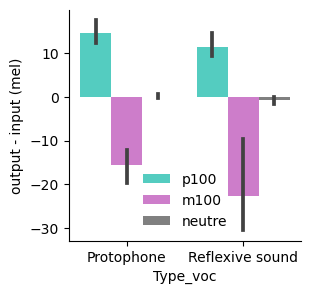

In [20]:
#### FIGURE : VERIFICATION TRANSFORMATION BY VOCALISATION TYPE:
plt.figure(figsize=[3,3])
sns.barplot(x="Type_voc", y="M_minus_NM", data= exp, hue = "cond", palette = condColor, units = "BB")
plt.ylabel(difference_legend)
sns.despine()
plt.legend(frameon = False)

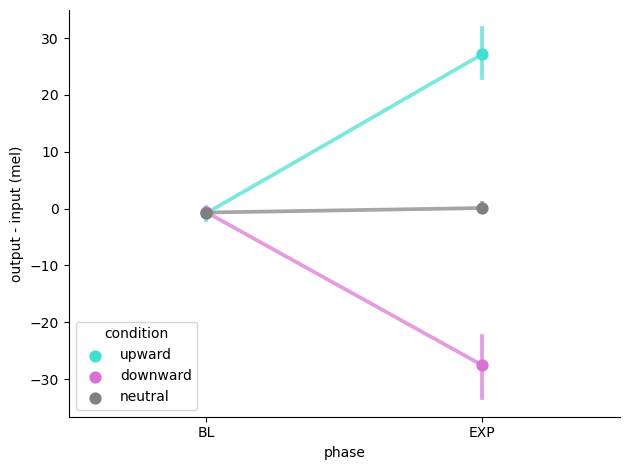

In [21]:
## FIGURE S1: Pitch tranformation (concat data)
ax = sns.pointplot(x="phase", y="M_minus_NM", data = dfc, hue = "cond", palette = condColor, units = "BB")
for line in ax.lines:
    line.set_alpha(0.7)
sns.despine()
plt.ylabel(difference_legend)
handles, labels = plt.gca().get_legend_handles_labels()
plt.legend(handles, ["upward", "downward", "neutral"], frameon=True, loc="lower left", fontsize=10, title = "condition")

# Enregistrer le graphique dans un fichier (png high quality, pdf)
filename = f"FIGURE_S1_transformation_CHECK.png"
filepath = os.path.join(output_dir, filename)
plt.tight_layout(pad=0.3)
plt.savefig(filepath, dpi=300, bbox_inches="tight")

filename_pdf = f"FIGURE_S1_transformation_CHECK.pdf"
filepath_pdf = os.path.join(output_dir, filename_pdf)
plt.tight_layout()
plt.savefig(filepath_pdf)

## VOCALISATION NUMBER BY TYPE ACROSS PHASES

15 17 B TtestResult(statistic=-1.2071670045906944, pvalue=0.2368000156573799, df=30.0)
29 25 Gr TtestResult(statistic=-0.7496350270278012, pvalue=0.4568527249396669, df=52.0)
18 24 L TtestResult(statistic=-1.5789582155950836, pvalue=0.12222217961816537, df=40.0)
12 11 R TtestResult(statistic=0.37407515729340607, pvalue=0.7120987613101998, df=21.0)
20 11 S TtestResult(statistic=-0.6812094216046438, pvalue=0.5011428990135578, df=29.0)
69 72 V TtestResult(statistic=-2.0402987459540767, pvalue=0.04321402278028284, df=139.0)
46 41 pB TtestResult(statistic=-1.6502746747041652, pvalue=0.10257738341414598, df=85.0)


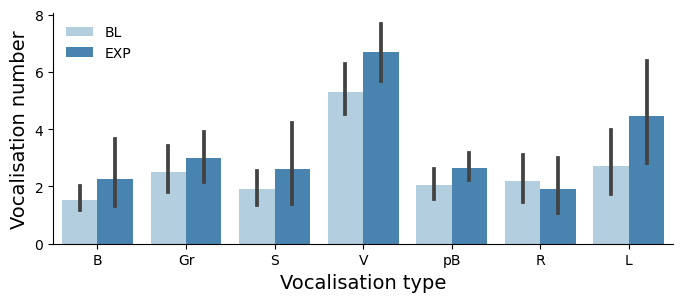

In [23]:
## FIGURE S7: Distribution of infant vocalisations by type and phase

count_vocs = df.groupby(["BB","Type_protophone","phase"])["age"].count().reset_index(name="count")
count_vocs = count_vocs[~count_vocs["Type_protophone"].isin(["UnS", "nan"])]

plt.figure(figsize=[8,3])
sns.barplot(x="Type_protophone", y="count", data = count_vocs, hue = "phase", palette = "Blues")
plt.ylabel("Vocalisation number", fontsize = 14)
plt.xlabel("Vocalisation type", fontsize = 14)
sns.despine()
plt.legend(frameon=False)

plt.savefig(output_dir + "FIG_S7_plot_number_of_vocs_per_sounds_type.pdf", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

plt.savefig(output_dir + "FIG_S7_plot_number_of_vocs_per_sounds_type.png", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

## STATS
for u in np.unique(count_vocs["Type_protophone"]):
    BLu = count_vocs.loc[((count_vocs["Type_protophone"] == u) & (count_vocs["phase"] == "BL"))]
    EXPu = count_vocs.loc[((count_vocs["Type_protophone"] == u) & (count_vocs["phase"] == "EXP"))]
    print(len(EXPu), len(BLu), u, stats.ttest_ind(BLu["count"], EXPu["count"]))

In [24]:
# ANOVA INTERACTION CONDITION/phase
model = ols('count ~ Type_protophone + phase + Type_protophone:phase', data=count_vocs).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                            sum_sq     df          F        PR(>F)
Type_protophone        1184.065847    6.0  21.601821  5.600659e-22
phase                    89.178772    1.0   9.761740  1.912975e-03
Type_protophone:phase    27.604641    6.0   0.503613  8.056555e-01
Residual               3617.674033  396.0        NaN           NaN


### MAIN ANALYSIS

C:\Users\Margherita\AppData\Local\Temp\ipykernel_80252\1372697425.py:74: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(
C:\Users\Margherita\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Margherita\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


p-value annotation legend:
ns: 5.00e-02 < p <= 1.00e+00
*: 1.00e-02 < p <= 5.00e-02
**: 1.00e-03 < p <= 1.00e-02
***: 1.00e-04 < p <= 1.00e-03
****: p <= 1.00e-04

p100 v.s. m100: t-test independent samples with Bonferroni correction, P_val=1.040e-03 stat=-3.733e+00
p100 v.s. neutre: t-test independent samples with Bonferroni correction, P_val=1.888e-02 stat=-2.712e+00


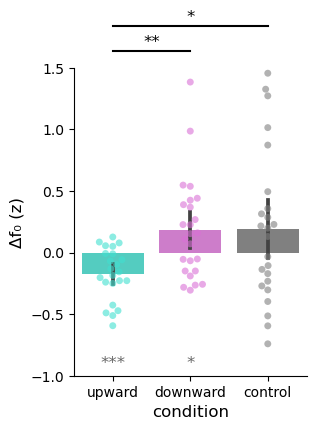

p100 vs. m100 TtestResult(statistic=-3.732844651105329, pvalue=0.0005198290375159648, df=46.0) 
 N p100? 23 N m100? 25 - d =  -1.0785160506239173
neutral vs. m100 TtestResult(statistic=0.09119253717859245, pvalue=0.9277271646295406, df=47.0) 
 N neutre? 24 N m100? 25 - d =  0.026060438184355845
neutral vs. p100 TtestResult(statistic=2.711956194430414, pvalue=0.00943930622347245, df=45.0) 
 N neutre? 24 N p100? 23 - d =  0.7913380715734847
neutre 0.19400735248572276 0.6017316613508411 TtestResult(statistic=1.5462483305544135, pvalue=0.13569460638064632, df=23) 0.322
+100 cent -0.1726362108822345 0.20536740911945567 TtestResult(statistic=-3.942863221141561, pvalue=0.0006932247711452877, df=22) -0.841
-100 cent 0.1804866989777102 0.3980552790180158 TtestResult(statistic=2.2213011164948626, pvalue=0.036018338199298464, df=24) 0.453


In [66]:
# CONCAT DATA 
pp = dfc_exp.copy()
pp["zf0c_Original_abs"] = pp["zf0c_Original"].abs()

order = ["p100", "m100", "neutre"]
labels = ["upward", "downward", "control"]


# ==============================================================
# Helper function: convert p-values to significance stars
# ==============================================================

def p_to_stars(p):
    if p < 0.001:
        return "***"
    elif p < 0.01:
        return "**"
    elif p < 0.05:
        return "*"
    else:
        return ""


# ==============================================================
# Extract data for each condition
# ==============================================================

pp100 = (
    pp.loc[pp["cond"] == "p100", "zf0c_Original"]
    .dropna()
)

mm100 = (
    pp.loc[pp["cond"] == "m100", "zf0c_Original"]
    .dropna()
)

neutre = (
    pp.loc[pp["cond"] == "neutre", "zf0c_Original"]
    .dropna()
)


# ==============================================================
# One-sample tests against zero
# ==============================================================

zero_tests = {
    "p100": stats.ttest_1samp(
        pp100,
        popmean=0,
        nan_policy="omit"
    ),
    "m100": stats.ttest_1samp(
        mm100,
        popmean=0,
        nan_policy="omit"
    ),
    "neutre": stats.ttest_1samp(
        neutre,
        popmean=0,
        nan_policy="omit"
    )
}


# ==============================================================
# Create plot
# ==============================================================

fig, ax = plt.subplots(figsize=(3, 4))

# Individual observations
sns.swarmplot(
    ax=ax,
    data=pp,
    x="cond",
    y="zf0c_Original",
    order=order,
    palette=condColor,
    alpha=0.6
)

# Bars with the default Seaborn error bars preserved
sns.barplot(
    ax=ax,
    data=pp,
    x="cond",
    y="zf0c_Original",
    order=order,
    palette=condColor,
    units="BB"
)


# ==============================================================
# Pairwise significance annotations
# ==============================================================

add_stat_annotation(
    ax,
    data=pp,
    x="cond",
    y="zf0c_Original",
    order=order,
    box_pairs=[
        ("p100", "m100"),
        ("p100", "neutre"),
        # ("m100", "neutre"),
    ],
    test="t-test_ind",
    text_format="star",
    loc="outside",
    line_height=0,
    color="black",
    line_offset=0.03,
    fontsize = 12,
    verbose=2
)


# ==============================================================
# Add black stars for one-sample tests against zero
# ==============================================================

star_y = -0.90

for x_position, condition in enumerate(order):
    p_value = zero_tests[condition].pvalue
    stars = p_to_stars(p_value)

    if stars:
        ax.text(
            x_position,
            star_y,
            stars,
            ha="center",
            va="center",
            color="0.4",
            fontsize=12,
            zorder=20
        )


# ==============================================================
# Figure formatting
# ==============================================================

sns.despine(ax=ax)

ax.set_ylabel("Δf₀ (z)", fontsize=fts)
ax.set_xlabel("condition", fontsize=fts)

ax.set_ylim(-1, 1.5)

ax.set_xticks(range(len(order)))
ax.set_xticklabels(labels)


# ==============================================================
# Save figure
# ==============================================================

fig.savefig(
    output_dir + "FIG2A_conditions.pdf",
    dpi="figure",
    format="pdf",
    bbox_inches="tight",
    pad_inches=0.1,
    facecolor="auto",
    edgecolor="auto"
)

fig.savefig(
    output_dir + "FIG2A_conditions.png",
    dpi="figure",
    format="png",
    bbox_inches="tight",
    pad_inches=0.1,
    facecolor="auto",
    edgecolor="auto"
)

plt.show()

## STATS: 
pp100 = pp.loc[pp["cond"] == "p100"]
mm100 = pp.loc[pp["cond"] == "m100"]
neutre = pp.loc[pp["cond"] == "neutre"]
print("p100 vs. m100", stats.ttest_ind(pp100["zf0c_Original"], mm100["zf0c_Original"]), "\n",
      "N p100?", len(pp100), "N m100?", len(mm100),
      "- d = ", cohend(pp100["zf0c_Original"], mm100["zf0c_Original"])) 

# if neutral cond are in:
neutre = pp.loc[pp["cond"] == "neutre"]
print("neutral vs. m100", stats.ttest_ind(neutre["zf0c_Original"], mm100["zf0c_Original"]), "\n",
  "N neutre?", len(neutre), "N m100?", len(mm100),
  "- d = ", cohend(neutre["zf0c_Original"], mm100["zf0c_Original"]))
print("neutral vs. p100", stats.ttest_ind(neutre["zf0c_Original"], pp100["zf0c_Original"]), "\n",
  "N neutre?", len(neutre), "N p100?", len(pp100),
  "- d = ", cohend(neutre["zf0c_Original"], pp100["zf0c_Original"]))
print("neutre", np.mean(neutre["zf0c_Original"]), np.std(neutre["zf0c_Original"]), 
      stats.ttest_1samp(neutre["zf0c_Original"], 0, nan_policy = "omit"), cohen_d_simple(neutre["zf0c_Original"], 0))
print("+100 cent", np.mean(pp100["zf0c_Original"]), 
      np.std(pp100["zf0c_Original"]), 
      stats.ttest_1samp(pp100["zf0c_Original"], 0, nan_policy = "omit"), cohen_d_simple(pp100["zf0c_Original"], 0))
print("-100 cent", np.mean(mm100["zf0c_Original"]), 
      np.std(mm100["zf0c_Original"]),
      stats.ttest_1samp(mm100["zf0c_Original"], 0, nan_policy = "omit"), cohen_d_simple(mm100["zf0c_Original"], 0))

### Figures supplementary other vocal features

C:\Users\Margherita\AppData\Local\Temp\ipykernel_24856\721791751.py:4: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x="cond", y="f0cSD_NM", data = pp, palette = condColor, alpha = 0.6)
C:\Users\Margherita\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Margherita\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


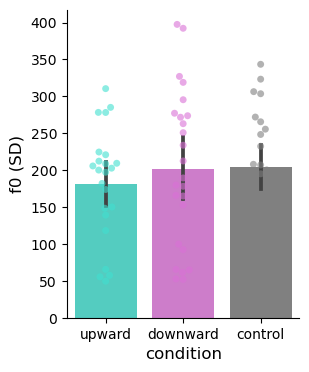

In [32]:
## f0 SD

plt.figure(figsize=[3,4])
sns.swarmplot(x="cond", y="f0cSD_NM", data = pp, palette = condColor, alpha = 0.6)
sns.barplot(x="cond", y="f0cSD_NM", data = pp, palette = condColor, units = "BB")
sns.despine()
plt.ylabel("f0 (SD)", fontsize=fts)
plt.xlabel("condition", fontsize=fts)
#plt.ylim([-1, 1.5])
plt.xticks(ticks=[0, 1,2], labels=["upward", "downward", "control"])

plt.savefig(output_dir + "FIGS4C_conditions.pdf", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)
plt.savefig(output_dir + "FIGS4C_conditions.png", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

In [33]:
# NO ≠ in the SD of the f0 between phases...
model = ols('f0sd_NM ~ cond*phase', data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

                  sum_sq      df         F    PR(>F)
cond        2.540323e+04     2.0  0.864572  0.421442
phase       4.527209e+03     1.0  0.308158  0.578896
cond:phase  1.616287e+04     2.0  0.550086  0.577016
Residual    2.202213e+07  1499.0       NaN       NaN


C:\Users\Margherita\AppData\Local\Temp\ipykernel_24856\1128359299.py:3: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x="cond", y="zf0c_Original_abs", data = pp, palette = condColor, alpha = 0.6)
C:\Users\Margherita\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Margherita\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


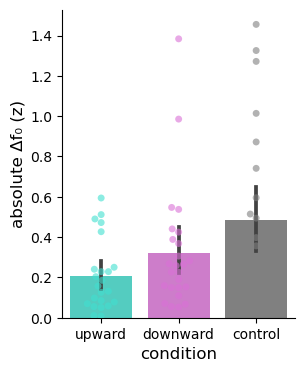

In [34]:
# CONCAT DATA NO STAT (magnitude)
plt.figure(figsize=[3,4])
sns.swarmplot(x="cond", y="zf0c_Original_abs", data = pp, palette = condColor, alpha = 0.6)
sns.barplot(x="cond", y="zf0c_Original_abs", data = pp, palette = condColor, units = "BB")
plt.xticks(ticks=[0, 1,2], labels=["upward", "downward", "control"])
plt.ylabel("absolute Δf₀ (z)", fontsize=fts)
plt.xlabel("condition", fontsize=fts)
sns.despine()

plt.savefig(output_dir + "FIGS3_conditions_magnitude.pdf", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)
plt.savefig(output_dir + "FIGS3_conditions_magnitude.png", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

In [35]:
# ANOVA INTERACTION CONDITION/phase
model = ols('zf0c_Original_abs ~ cond', data=pp).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

            sum_sq    df         F   PR(>F)
cond      0.926438   2.0  4.721675  0.01197
Residual  6.769233  69.0       NaN      NaN


In [36]:
## STATS for absolute values
print("abs values")
print("p100 vs. m100", stats.ttest_ind(pp100["zf0c_Original_abs"], mm100["zf0c_Original_abs"]), "\n",
      "- d = ", cohend(pp100["zf0c_Original_abs"], mm100["zf0c_Original_abs"])) 
print("neutre vs. m100", stats.ttest_ind(neutre["zf0c_Original_abs"], mm100["zf0c_Original_abs"]))
print("neutre vs. p100", stats.ttest_ind(neutre["zf0c_Original_abs"], pp100["zf0c_Original_abs"]))
print("+100 cent", np.mean(pp100["zf0c_Original_abs"]), 
      np.std(pp100["zf0c_Original_abs"]))
print("-100 cent", np.mean(mm100["zf0c_Original_abs"]), 
      np.std(mm100["zf0c_Original_abs"]))
print("neutre", np.mean(neutre["zf0c_Original_abs"]), np.std(neutre["zf0c_Original_abs"]))

abs values
p100 vs. m100 TtestResult(statistic=-1.60859386893186, pvalue=0.11454788533777967, df=46.0) 
 - d =  -0.46476466843176006
neutre vs. m100 TtestResult(statistic=1.5880166182869926, pvalue=0.11898801840104575, df=47.0)
neutre vs. p100 TtestResult(statistic=2.992997357429684, pvalue=0.004474177454564002, df=45.0)
+100 cent 0.20695828166363414 0.17072581435462264
-100 cent 0.32254388611302576 0.2949387990636167
neutre 0.4860192600449989 0.40435766835299974


NB de bbs? 72
mean value: 0.17672500676529476 0.32054579689716794 TtestResult(statistic=3.779695810596052, pvalue=0.00044216931694183553, df=47) d: 0.551
N compensate as expected? 33  - N no change? 0  - N go in the unexpected direction? 15
chisq N expected vs. unexpected Power_divergenceResult(statistic=6.75, pvalue=0.0093747684594349)


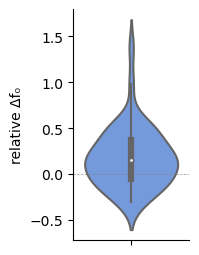

In [37]:
#### DIFFERENCE AGASINT ZERO
plt.figure(figsize=[1.5,3])
plt.axhline(y=0, linewidth=0.5, color = 'grey', linestyle = "--", alpha = 0.8)
sns.violinplot(y="zf0c_Original_inv", data=pp, color="cornflowerblue")#, ax=axA)
plt.ylabel("relative Δf₀")
sns.despine()

## STATS 
print("NB de bbs?", len(pp))
expected = len(pp.loc[pp["zf0c_Original_inv"] > 0])
no_change = len(pp.loc[pp["zf0c_Original_inv"] == 0])
not_expected = len(pp.loc[pp["zf0c_Original_inv"] < 0])
print("mean value:", np.nanmean(pp["zf0c_Original_inv"]), np.nanstd(pp["zf0c_Original_inv"]),
     stats.ttest_1samp(pp["zf0c_Original_inv"], 0, nan_policy="omit"), 
      "d:", cohen_d_simple(pp["zf0c_Original_inv"], 0))
print("N compensate as expected?", expected, " - N no change?", no_change, " - N go in the unexpected direction?", not_expected)
print("chisq N expected vs. unexpected", stats.chisquare([expected, not_expected]))

In [38]:
pp

,index,BB,cond,perm_cond,phase,age,age_c,f0c_NM,f0c_M,f0cSD_NM,f0cSD_M,M_minus_NM,zf0c_Original,zf0c_Original_inv,zf0c_Original_abs
0,1,1,p100,p100,EXP,6.100000,6,551.153539,582.991709,285.082806,302.230033,31.838170,0.085077,-0.085077,0.085077
1,3,12,m100,p100,EXP,6.300000,6,428.422167,384.372728,189.443424,175.459353,-44.049439,0.388435,0.388435,0.388435
2,5,15,p100,m100,EXP,6.466667,6,360.884324,401.614118,57.449828,62.169957,40.729794,-0.489990,0.489990,0.489990
3,7,18,m100,m100,EXP,7.166667,6,763.869172,682.240137,327.068743,290.807528,-81.629034,0.368051,0.368051,0.368051
4,9,21,m100,p100,EXP,6.466667,6,359.574919,322.199334,64.777478,56.828348,-37.375584,-0.305788,-0.305788,0.305788
5,11,23,m100,p100,EXP,6.433333,6,471.936569,421.926036,178.147666,164.063480,-50.010532,0.537531,0.537531,0.537531
6,13,24,p100,p100,EXP,3.633333,4,454.747336,505.841490,278.156788,312.958304,51.094154,0.126087,-0.126087,0.126087
7,15,27,m100,p100,EXP,3.566667,4,402.477709,358.663568,52.620056,47.157461,-43.814142,-0.052494,-0.052494,0.052494
8,17,31,m100,p100,EXP,3.800000,4,324.337698,288.576014,65.466613,56.967591,-35.761684,-0.258021,-0.258021,0.258021
9,19,36,p100,m100,EXP,3.733333,4,474.592212,523.781027,209.335789,232.173781,49.188815,-0.472149,0.472149,0.472149


NB de bbs? 24
mean value: 0.19400735248572276 0.6017316613508411 TtestResult(statistic=1.5462483305544135, pvalue=0.13569460638064632, df=23) d: 0.322
N neutral compensate as expected? 13  - N no change? 0  - N go in the unexpected direction? 11
chisq N expected vs. unexpected Power_divergenceResult(statistic=0.16666666666666666, pvalue=0.6830913983096086)


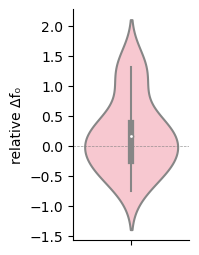

In [39]:
## above but neutral only
pp_neutral = pp.loc[pp["cond"] == "neutre"]

#### difference against zero
plt.figure(figsize=[1.5,3])
plt.axhline(y=0, linewidth=0.5, color = 'grey', linestyle = "--", alpha = 0.8)
sns.violinplot(y="zf0c_Original", data=pp_neutral, color="pink")#, ax=axA)
plt.ylabel("relative Δf₀")
sns.despine()

## STATS 
print("NB de bbs?", len(pp_neutral))
expected_n = len(pp_neutral.loc[pp_neutral["zf0c_Original"] > 0])
no_change_n = len(pp_neutral.loc[pp_neutral["zf0c_Original"] == 0])
not_expected_n = len(pp_neutral.loc[pp_neutral["zf0c_Original"] < 0])
print("mean value:", np.nanmean(pp_neutral["zf0c_Original"]), np.nanstd(pp_neutral["zf0c_Original"]),
     stats.ttest_1samp(pp_neutral["zf0c_Original"], 0, nan_policy="omit"), 
      "d:", cohen_d_simple(pp_neutral["zf0c_Original"], 0))
print("N neutral compensate as expected?", expected_n, " - N no change?", no_change_n, " - N go in the unexpected direction?", not_expected_n)
print("chisq N expected vs. unexpected", stats.chisquare([expected_n, not_expected_n]))


In [40]:
## MIRROR TEST STAT
#df_expected = pp.loc[pp[""]]
mir = df.groupby(["BB"])["Mirror_recognition"].mean().reset_index()
pass_mir = len(mir.loc[mir["Mirror_recognition"]==1])
fail_mir = len(mir.loc[mir["Mirror_recognition"]==0])
p_mir = (pass_mir)/((pass_mir) + (fail_mir))
p_voc = (expected)/((expected) + (no_change) + (not_expected))
print("pass_mir", (pass_mir), "fail_mir", (fail_mir), "% passing:", p_mir)
print("chisq N pass_mir vs. not", stats.chisquare([pass_mir, fail_mir]))
print("pass_voc", (expected), "fail_voc", no_change + not_expected, "% passing:", p_voc)
print("chisq N expected vs. unexpected", stats.chisquare([expected, not_expected]))
print("chisq N pass_voc (expected) vs. pass_mir", stats.chisquare([expected, pass_mir]))

pass_mir 0 fail_mir 57 % passing: 0.0
chisq N pass_mir vs. not Power_divergenceResult(statistic=57.0, pvalue=4.3581190270320824e-14)
pass_voc 33 fail_voc 15 % passing: 0.6875
chisq N expected vs. unexpected Power_divergenceResult(statistic=6.75, pvalue=0.0093747684594349)
chisq N pass_voc (expected) vs. pass_mir Power_divergenceResult(statistic=33.0, pvalue=9.215887201256233e-09)


0.0502751272913575 0.480644532786217


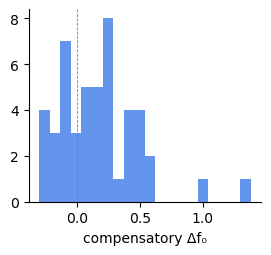

In [41]:
## DISTRIBUTION OF the effect?
nonan = pp.loc[~np.isnan(pp["zf0c_Original_inv"])]

plt.figure(figsize=[3,2.5])
plt.hist(x="zf0c_Original_inv", data=pp, color="cornflowerblue", bins=20)#, ax=axA)
plt.axvline(x=0, linewidth=0.6, color = 'Grey', linestyle = "--")
plt.xlabel("compensatory Δf₀")
sns.despine()
plt.savefig(output_dir + "FIGS9.pdf", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)
plt.savefig(output_dir + "FIGS9.png", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

# Hartigan's Dip Test: Measures the distance between the empirical distribution and the best unimodal distribution.
# A low p-value (p < 0.05) means you reject unimodality (it has more than one peak).
# both the dip statistic and p-value
dip, pval = diptest.diptest(nonan["zf0c_Original_inv"])
print(dip, pval)

len b4 862 len after exclusion 862
[  1  12  15  18  21  23  24  27  31  36  38  45  47  52  56  58  61  66
  68  69  70  71  72  74  77  78  81  88  90  91  92  94  96  99 100 101
 103 104 109 110 111 112 114 115 116 117 118 119 120 121 122 123 125 127
 129 130 131 133 134 141 142 143 144 148 149 150 155 156 159 160 161 163]
SignificanceResult(statistic=-0.1432304895940932, pvalue=2.7431279476118892e-05)


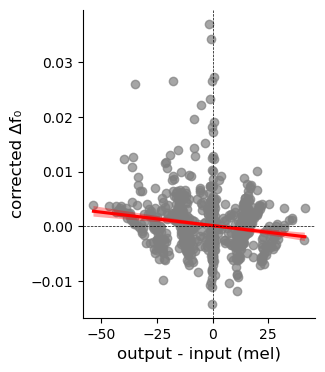

In [42]:
#### ANALYSIS PER VOC (fig 2c)
BIG = exp
BIG_m = BIG.groupby(["BB", "cond", "age"])[["zf0_Original", "zf0_Original_inv", "f0m_NM","M_minus_NM","zf0_Original_abs", 
#                                            "total_nb_voc", "bl_nb_voc", "exp_nb_voc", "nb_protophones", 
                                            "zHNR_Original", "zRMS_Original"]].mean().reset_index()
print("len b4", len(exp), "len after exclusion",len(BIG))
print(np.unique(BIG_m["BB"]))

BIG["rel"] = BIG["zf0_Original"]/BIG["f0m_NM"]
fig, ax = plt.subplots(figsize=[3,4])
sns.regplot(x="M_minus_NM", y="rel", data = BIG, order = 1, 
            scatter_kws={'alpha':0.7, 'color':'Grey'},
           line_kws={'alpha':1, 'color':'Red'})
#sns.swarmplot(x="M_minus_NM", y="zf0_Original", data = BIG, hue = "cond")
plt.ylabel("corrected Δf₀", fontsize = fts)
#plt.title('all vocalizations', fontsize = fts)
plt.xlabel(difference_legend, fontsize = fts)
plt.axhline(y=0, linewidth=0.5, color = 'k', linestyle = "--")
plt.axvline(x=0, linewidth=0.5, color = 'k', linestyle = "--")
plt.setp(ax.collections[1], alpha=0.35)
#plt.ylim([-0.1, 2])
sns.despine()
#plt.title("transposition vs. compensation", fontsize = fts)

print(stats.spearmanr(BIG["M_minus_NM"], BIG["rel"], nan_policy="omit"))

plt.savefig(output_dir + "FIG2C.pdf", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)
plt.savefig(output_dir + "FIG2C.png", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

SignificanceResult(statistic=-0.172111152978677, pvalue=0.007920184939448812)
SignificanceResult(statistic=-0.13397460364282213, pvalue=0.0008746879321128636)


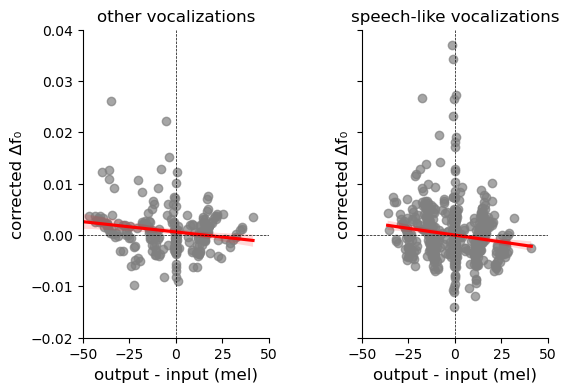

In [43]:
# per type of voc (figure s2)
fig, axes = plt.subplots(
    1, 2,
    figsize=(6, 4),
    sharey=True
)

fig.subplots_adjust(wspace=0.5)

titles = ["other vocalizations", "speech-like vocalizations"]

for i, ax in enumerate(axes):
    ccc = BIG.loc[BIG["is_margbabbling"] == i]

    sns.regplot(
        x="M_minus_NM",
        y="rel",
        data=ccc,
        order=1,
        ax=ax,
        scatter_kws={"alpha": 0.7, "color": "grey"},
        line_kws={"alpha": 1, "color": "red"}
    )

    ax.set_ylabel("corrected Δf₀", fontsize=fts)
    ax.set_xlabel(difference_legend, fontsize=fts)

    ax.axhline(
        y=0,
        linewidth=0.5,
        color="black",
        linestyle="--"
    )
    ax.axvline(
        x=0,
        linewidth=0.5,
        color="black",
        linestyle="--"
    )

    ax.set_ylim(-0.02, 0.04)
    ax.set_xlim(-50, 50)
    ax.set_title(titles[i])

    sns.despine(ax=ax)

    print(
        stats.spearmanr(
            ccc["M_minus_NM"],
            ccc["rel"],
            nan_policy="omit"
        )
    )

fig.savefig(
    output_dir + "FIGS2.pdf",
    bbox_inches="tight",
    pad_inches=0.1
)

fig.savefig(
    output_dir + "FIGS2.png",
    dpi=300,
    bbox_inches="tight",
    pad_inches=0.1
)

plt.show()

SignificanceResult(statistic=-0.0910933966277794, pvalue=0.007837483749371632)


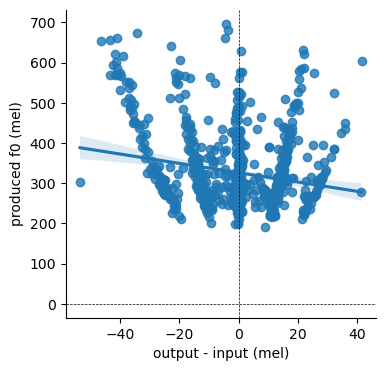

In [44]:
## RAW MEL PLOT
plt.figure(figsize=[4,4])
sns.regplot(x="M_minus_NM", y="f0m_NM", data = BIG, order = 1)
plt.ylabel("produced f0 (mel)")
plt.xlabel(difference_legend)
plt.axhline(y=0, linewidth=0.5, color = 'k', linestyle = "--")
plt.axvline(x=0, linewidth=0.5, color = 'k', linestyle = "--")
sns.despine()
print(stats.spearmanr(BIG["M_minus_NM"], BIG["f0m_NM"], nan_policy="omit"))

### AGE EFFECT?

SignificanceResult(statistic=-0.06096836007756371, pvalue=0.6805958739687378)


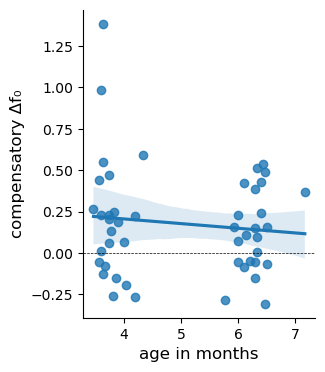

In [46]:
## FIGURE 3C: AGE EFFECT WITH CONCAT DATA
plt.figure(figsize=[3,4])

sns.regplot(x="age", y="zf0c_Original_inv", data=pp)
plt.axhline(y=0, linewidth=0.5, color = 'k', linestyle = "--")
plt.ylabel("compensatory Δf₀", fontsize = fts)
plt.xlabel("age in months", fontsize = fts)
sns.despine()

plt.savefig(output_dir + "FIG2B_age_concat.pdf", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)
plt.savefig(output_dir + "FIG2B_age_concat.png", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)
# STATS
print(stats.spearmanr(pp["age"], pp["zf0c_Original_inv"], nan_policy="omit"))

## MUM

C:\Users\Margherita\AppData\Local\Temp\ipykernel_24856\3806088952.py:6: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x="cond", y="zf0c_Original", data = dfc_mum_exp, palette = condColor, alpha = 0.6)
C:\Users\Margherita\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Margherita\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


TtestResult(statistic=0.959746647973673, pvalue=0.34376632457475864, df=35.0) 
 N p100? 16 N m100? 21 - d =  0.31848415266219793
+100 cent 0.23755085451247057 TtestResult(statistic=0.8520094765119545, pvalue=0.4076066066097148, df=15)
-100 cent -0.2128326570149111 TtestResult(statistic=-0.608763906130507, pvalue=0.5495336156146694, df=20)


<Figure size 300x400 with 0 Axes>

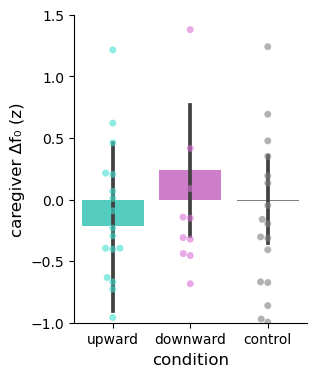

In [48]:
## FIGURE S6: with concatenated data 
plt.figure(figsize=[3,4])
order = ["p100", "m100", "neutre"]

plt.figure(figsize=[3,4])
sns.swarmplot(x="cond", y="zf0c_Original", data = dfc_mum_exp, palette = condColor, alpha = 0.6)
sns.barplot(x="cond", y="zf0c_Original", data = dfc_mum_exp, palette = condColor, units = "BB")
sns.despine()
plt.ylabel("caregiver Δf₀ (z)", fontsize=fts)
plt.xlabel("condition", fontsize=fts)
plt.ylim([-1, 1.5])
plt.xticks(ticks=[0, 1,2], labels=["upward", "downward", "control"])

plt.savefig(output_dir + "FIGS6_conditions.pdf", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)
plt.savefig(output_dir + "FIGS6_conditions.png", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

## STATS
dfc_mum_exp100 = dfc_mum_exp.loc[dfc_mum_exp["cond"] == "p100"]
mm100 = dfc_mum_exp.loc[dfc_mum_exp["cond"] == "m100"]
print(stats.ttest_ind(dfc_mum_exp100["zf0c_Original"], mm100["zf0c_Original"]), "\n",
      "N p100?", len(dfc_mum_exp100), "N m100?", len(mm100),
      "- d = ", cohend(dfc_mum_exp100["zf0c_Original"], mm100["zf0c_Original"])) 
print("+100 cent", np.mean(dfc_mum_exp100["zf0c_Original"]), stats.ttest_1samp(dfc_mum_exp100["zf0c_Original"], 0, nan_policy = "omit"))
print("-100 cent", np.mean(mm100["zf0c_Original"]), stats.ttest_1samp(mm100["zf0c_Original"], 0, nan_policy = "omit"))

### HNR analysis

C:\Users\Margherita\AppData\Local\Temp\ipykernel_24856\1194568543.py:3: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x="cond", y="zHNR_Original", data = BIG_m, palette = condColor, alpha = 0.6)
C:\Users\Margherita\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Margherita\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


TtestResult(statistic=0.013038166684281689, pvalue=0.9896537276062949, df=46.0) 
 N p100? 23 N m100? 25 N neutre? 24 - d =  0.0037670659655080945
+100 cent -0.049482202073098815 TtestResult(statistic=-0.3037669144033919, pvalue=0.7641598146646525, df=22)
-100 cent -0.052233575208075235 TtestResult(statistic=-0.3838217318312142, pvalue=0.7044899237406304, df=24)
neutre TtestResult(statistic=-1.304782884436072, pvalue=0.20487162310303184, df=23)
neutre vs p100 TtestResult(statistic=-0.6362455474880773, pvalue=0.5278394650602366, df=45.0)
neutre vs m100 TtestResult(statistic=-0.6833462707037266, pvalue=0.49774311024789664, df=47.0)
p100 vs m100 TtestResult(statistic=0.013038166684281689, pvalue=0.9896537276062949, df=46.0)


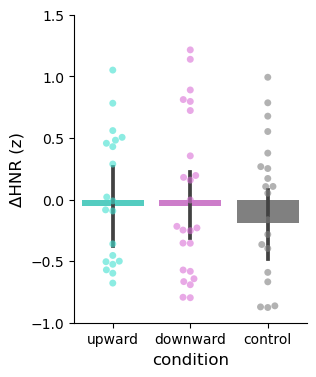

In [50]:
#### FIGURE S4: HNR by cond
plt.figure(figsize=[3,4])
sns.swarmplot(x="cond", y="zHNR_Original", data = BIG_m, palette = condColor, alpha = 0.6)
sns.barplot(x="cond", y="zHNR_Original", data = BIG_m, palette = condColor, units = "BB")
sns.despine()
plt.ylabel("ΔHNR (z)", fontsize=fts)
plt.xlabel("condition", fontsize=fts)
plt.ylim([-1, 1.5])
plt.xticks(ticks=[0, 1,2], labels=["upward", "downward", "control"])

plt.savefig(output_dir + "FIGS4A_conditions.pdf", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)
plt.savefig(output_dir + "FIGS4A_conditions.png", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

p100 = BIG_m.loc[BIG_m["cond"] == "p100"]
m100 = BIG_m.loc[BIG_m["cond"] == "m100"]
neutre = BIG_m.loc[BIG_m["cond"] == "neutre"]

# STATS
print(stats.ttest_ind(p100["zHNR_Original"], m100["zHNR_Original"]), "\n",
      "N p100?", len(p100), "N m100?", len(m100), "N neutre?", len(neutre),
      "- d = ", cohend(p100["zHNR_Original"], m100["zHNR_Original"])) 
print("+100 cent", np.mean(p100["zHNR_Original"]), stats.ttest_1samp(p100["zHNR_Original"], 0, nan_policy = "omit"))
print("-100 cent", np.mean(m100["zHNR_Original"]), stats.ttest_1samp(m100["zHNR_Original"], 0, nan_policy = "omit"))
print("neutre", stats.ttest_1samp(neutre["zHNR_Original"], 0, nan_policy = "omit"))
print("neutre vs p100", stats.ttest_ind(neutre["zHNR_Original"], p100["zHNR_Original"], nan_policy = "omit"))
print("neutre vs m100", stats.ttest_ind(neutre["zHNR_Original"], m100["zHNR_Original"], nan_policy = "omit"))
print("p100 vs m100", stats.ttest_ind(p100["zHNR_Original"], m100["zHNR_Original"], nan_policy = "omit"))

In [51]:
# ANOVA INTERACTION CONDITION/phase
model = ols('zHNR_Original ~ cond', data=BIG_m).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

             sum_sq    df         F    PR(>F)
cond       0.297766   2.0  0.286034  0.752123
Residual  35.915020  69.0       NaN       NaN


C:\Users\Margherita\AppData\Local\Temp\ipykernel_24856\3214694353.py:3: FutureWarning: Passing `palette` without assigning `hue` is deprecated.
  sns.swarmplot(x="cond", y="zRMS_Original", data = BIG_m, palette = condColor, alpha = 0.6)
C:\Users\Margherita\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
C:\Users\Margherita\anaconda3\Lib\site-packages\seaborn\_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


+100 cent 0.4005022942258644 TtestResult(statistic=1.9339690361659012, pvalue=0.06608360310169224, df=22)
-100 cent 0.5652107429359757 TtestResult(statistic=2.697467124983496, pvalue=0.01257950941178884, df=24)
neutre 0.47223499896609783 TtestResult(statistic=1.5856600786449806, pvalue=0.126470717409929, df=23)
neutre vs p100 TtestResult(statistic=0.196181985032267, pvalue=0.8453510034604341, df=45.0)
neutre vs m100 TtestResult(statistic=-0.2570354376293108, pvalue=0.7982733556656612, df=47.0)
p100 vs m100 TtestResult(statistic=-0.5578200783153825, pvalue=0.5796720475869173, df=46.0) 
 N p100? 23 N m100? 25 N neutre? 24 - d =  -0.161168750391283


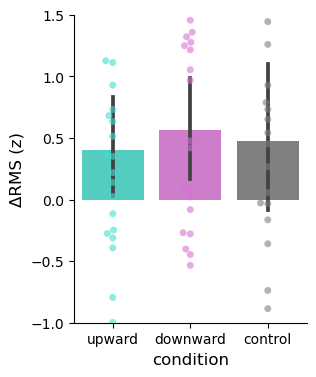

In [52]:
#### FIGURE S4 : RMS by cond
plt.figure(figsize=[3,4])
sns.swarmplot(x="cond", y="zRMS_Original", data = BIG_m, palette = condColor, alpha = 0.6)
sns.barplot(x="cond", y="zRMS_Original", data = BIG_m, palette = condColor, units = "BB")
sns.despine()
plt.ylabel("ΔRMS (z)", fontsize=fts)
plt.xlabel("condition", fontsize=fts)
plt.ylim([-1, 1.5])
plt.xticks(ticks=[0, 1,2], labels=["upward", "downward", "control"])

plt.savefig(output_dir + "FIGS4B_conditions.pdf", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)
plt.savefig(output_dir + "FIGS4B_conditions.png", dpi='figure', format=None, metadata=None,
            bbox_inches = "tight", pad_inches=0.1,
            facecolor='auto', edgecolor='auto',
            backend=None)

p100 = BIG_m.loc[BIG_m["cond"] == "p100"]
m100 = BIG_m.loc[BIG_m["cond"] == "m100"]
neutre = BIG_m.loc[BIG_m["cond"] == "neutre"]

print("+100 cent", np.mean(p100["zRMS_Original"]), stats.ttest_1samp(p100["zRMS_Original"], 0, nan_policy = "omit"))
print("-100 cent", np.mean(m100["zRMS_Original"]), stats.ttest_1samp(m100["zRMS_Original"], 0, nan_policy = "omit"))
print("neutre", np.mean(neutre["zRMS_Original"]), stats.ttest_1samp(neutre["zRMS_Original"], 0, nan_policy = "omit"))
print("neutre vs p100", stats.ttest_ind(neutre["zRMS_Original"], p100["zRMS_Original"], nan_policy = "omit"))
print("neutre vs m100", stats.ttest_ind(neutre["zRMS_Original"], m100["zRMS_Original"], nan_policy = "omit"))
print("p100 vs m100", stats.ttest_ind(p100["zRMS_Original"], m100["zRMS_Original"]), "\n",
      "N p100?", len(p100), "N m100?", len(m100), "N neutre?", len(neutre),
      "- d = ", cohend(p100["zRMS_Original"], m100["zRMS_Original"]))

In [53]:
# ANOVA INTERACTION CONDITION/phase
model = ols('zRMS_Original ~ cond', data=BIG_m).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print(anova_table)

             sum_sq    df         F    PR(>F)
cond       0.328141   2.0  0.116707  0.890021
Residual  97.002059  69.0       NaN       NaN


### Save data for STATS

In [55]:
## SAVES DATA FOR STATS in R
title = "N" + str(nsuj) + "_B.csv"
print(title)

BIG[["BB", "voc_nb_all", "cond", "age", "zf0_Original", "M_minus_NM", "Type_protophone",
     "zf0_Original_inv", "difference_inv", "f0m_NM","is_margbabbling"]].to_csv(title, sep=";")

### AND MERGED DATA
#both = both[~np.isnan(both["M_minus_NM_mum"])]
#both[["BB", "cond", "age", "zf0_Original", "zf0_Original_mum", "M_minus_NM", "M_minus_NM_mum"]].to_csv("N" + str(nsuj) + "_both.csv", sep=";")

### TRANSFO DATA
dfc[["BB", "cond", "age", "phase", "M_minus_NM"]].to_csv("N" + str(nsuj) + "_phases.csv", sep=";")

### concat data
pp[["BB", "cond", "age","age_c", "phase", "M_minus_NM", "zf0c_Original", "zf0c_Original_inv", "zf0c_Original_abs"]].to_csv("N" + str(nsuj) + "_concat.csv", sep=";")

N72_B.csv
